=== Decision Tree Report ===
                 precision    recall  f1-score   support

  Mental Health       0.83      0.83      0.83        12
Time Management       0.92      0.92      0.92        26

       accuracy                           0.89        38
      macro avg       0.88      0.88      0.88        38
   weighted avg       0.89      0.89      0.89        38



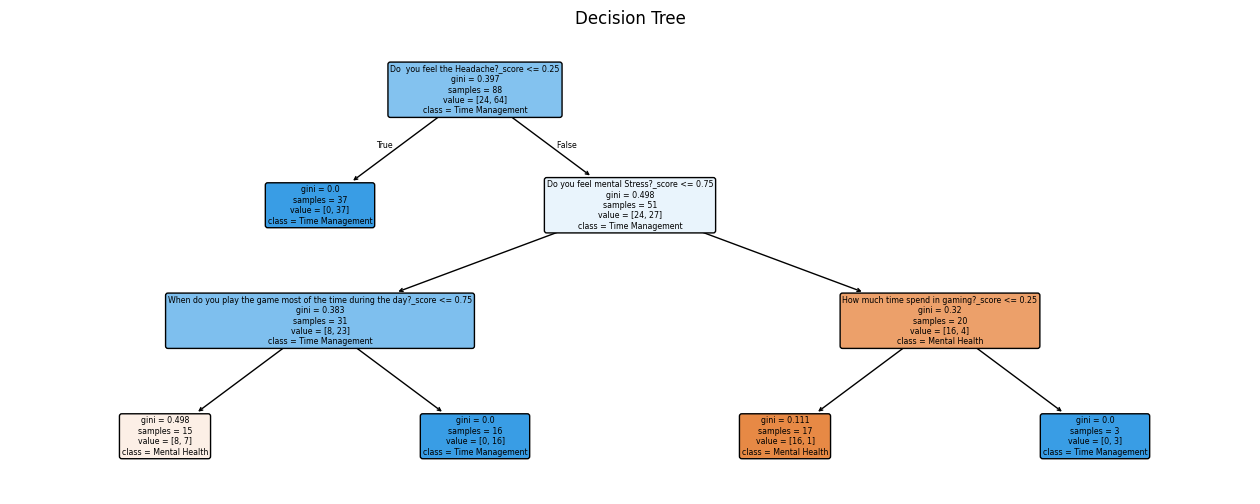

=== Logistic Regression Report ===
                 precision    recall  f1-score   support

  Mental Health       1.00      0.58      0.74        12
Time Management       0.84      1.00      0.91        26

       accuracy                           0.87        38
      macro avg       0.92      0.79      0.82        38
   weighted avg       0.89      0.87      0.86        38

Logistic Regression Feature Coefficients:
How much time spend in gaming?_score: 1.4793
When do you play the game most of the time during the day?_score: 1.8828
Do you feel Hamper in sleep?_score: -1.3761
Do  you feel the Headache?_score: -1.6359
Do you feel mental Stress?_score: -1.8010

Decision Tree Feature Importances:
How much time spend in gaming?_score: 0.1767
When do you play the game most of the time during the day?_score: 0.1723
Do you feel Hamper in sleep?_score: 0.0000
Do  you feel the Headache?_score: 0.3716
Do you feel mental Stress?_score: 0.2794


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("student.csv")
df.columns = [col.strip() for col in df.columns]  # Clean column names

# Define question columns
time_mgmt_cols = ["How much time spend in gaming?",
                  "When do you play the game most of the time during the day?"]

mental_health_cols = ["Do you feel Hamper in sleep?",
                      "Do  you feel the Headache?",
                      "Do you feel mental Stress?"]

# Scoring map
score_map = {
    "No": 0, "Sometimes": 0.5, "Yes": 1,
    "<2 hours": 0, "3-4 hours": 0.5, ">5 hours": 1,
    "Morning": 0, "Evening": 0.5, "Mid-Night": 1
}

# Apply scores
for col in time_mgmt_cols + mental_health_cols:
    df[col + "_score"] = df[col].map(score_map)

# Apply updated weights
df["Time_Management_Score"] = df[[col + "_score" for col in time_mgmt_cols]].mean(axis=1) * 1.5
df["Mental_Health_Score"] = df[[col + "_score" for col in mental_health_cols]].mean(axis=1) * 1.0

# Classification label
df["Classification"] = df.apply(
    lambda row: "Mental Health" if row["Mental_Health_Score"] > row["Time_Management_Score"] else "Time Management",
    axis=1
)

# Prepare features and labels
features = [col + "_score" for col in time_mgmt_cols + mental_health_cols]
X = df[features].dropna()
y = df.loc[X.index, "Classification"]

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# --- Decision Tree ---
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train, y_train)
tree_preds = tree_clf.predict(X_test)
print("=== Decision Tree Report ===")
print(classification_report(y_test, tree_preds, target_names=label_encoder.classes_))

# Plot tree
plt.figure(figsize=(16, 6))
plot_tree(tree_clf, feature_names=X.columns, class_names=label_encoder.classes_,
          filled=True, rounded=True)
plt.title("Decision Tree")
plt.show()

# --- Logistic Regression ---
logit_clf = LogisticRegression()
logit_clf.fit(X_train, y_train)
logit_preds = logit_clf.predict(X_test)
print("=== Logistic Regression Report ===")
print(classification_report(y_test, logit_preds, target_names=label_encoder.classes_))

# Show logistic regression coefficients
print("Logistic Regression Feature Coefficients:")
for name, coef in zip(X.columns, logit_clf.coef_[0]):
    print(f"{name}: {coef:.4f}")

# Show feature importances from decision tree
print("\nDecision Tree Feature Importances:")
for name, imp in zip(X.columns, tree_clf.feature_importances_):
    print(f"{name}: {imp:.4f}")
